In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv('Case1.csv')
print(df.head())

   Quarter  BEACON  DRAPER  FILMORE  LAKESIDE  MARE VALLEY  NORTH  OAKLEY  \
0  2017 Q1      69     130       85       117           16     74      61   
1  2017 Q2      77      86       97       107           17     71      55   
2  2017 Q3      63      90       92       127           18     68      55   
3  2017 Q4      61     100       95       132           21     72      72   
4  2018 Q1      67     106       92       145           21     69      79   

   ORLY  PIERCE  ROSEDALE  SEALY  SOUTHLAKE  WESTLAKE  WILDLAND  REGIONAL AVG  
0    51      35        65     93         72        83        83            74  
1    61      32        55     89         64        73        79            69  
2    67      32        59     79         58        73        81            69  
3    51      49        53     82         77        85        75            73  
4    51      49        59     94         87        87        79            78  


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/01/0387wy5106n9sws7xqt967740000gn/T/ipykernel_26575/1826766199.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['Year'] = df['Quarter'].str.extract('(\d{4})')[0].astype(int)


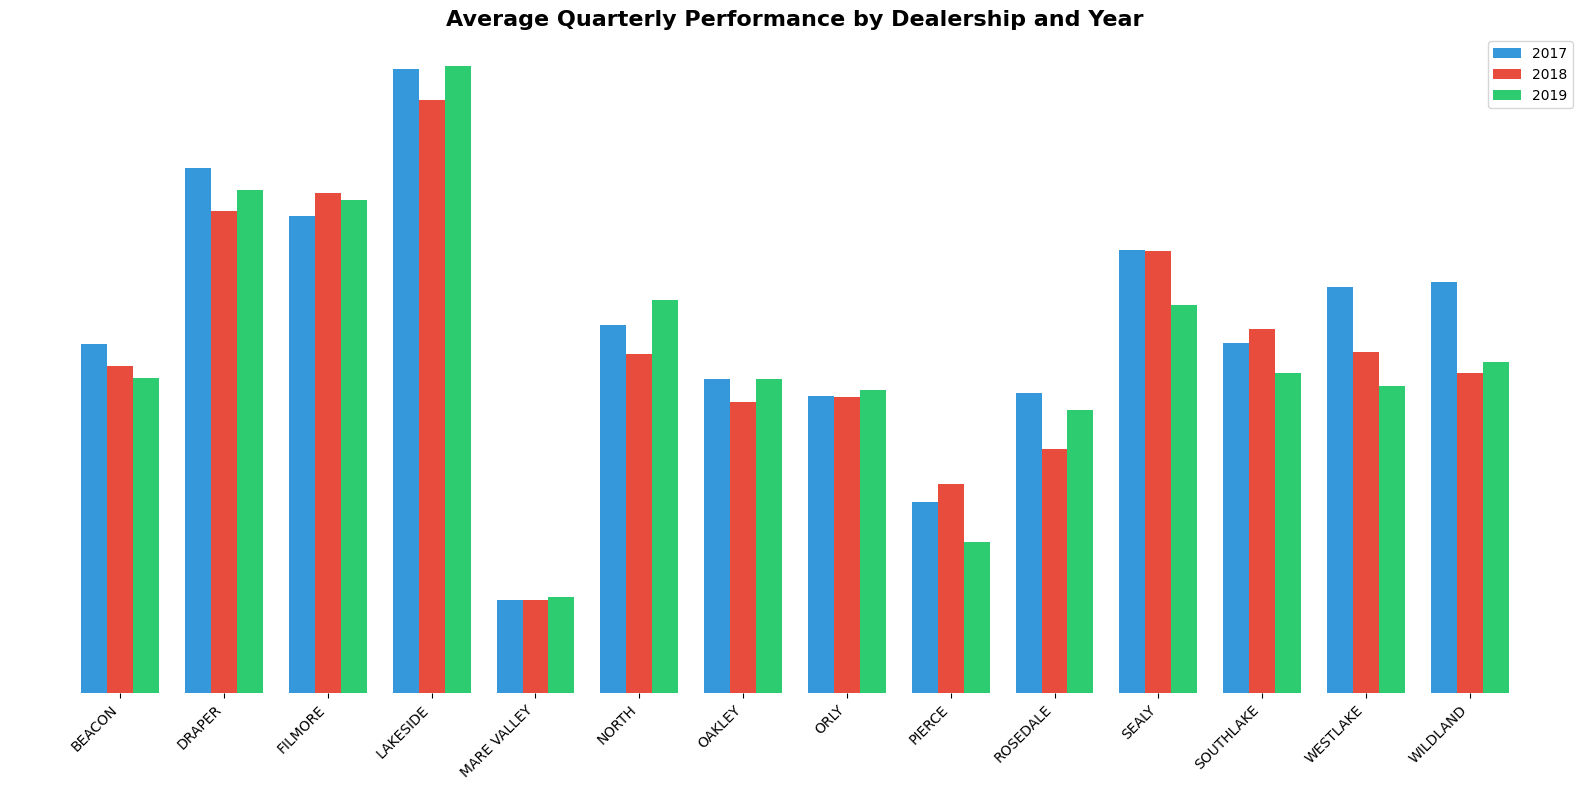

In [18]:
df['Year'] = df['Quarter'].str.extract('(\d{4})')[0].astype(int)

locations = [col for col in df.columns[1:] if col not in ['Year', 'REGIONAL AVG']]

yearly_avg = {}
for year in [2017, 2018, 2019]:
    year_data = df[df['Year'] == year]
    yearly_avg[year] = year_data[locations].mean()

df_plot = pd.DataFrame(yearly_avg).T
df_plot.index.name = 'Year'

x = np.arange(len(locations))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 8))

bars1 = ax.bar(x - width, df_plot.loc[2017], width, label='2017', color='#3498db')
bars2 = ax.bar(x, df_plot.loc[2018], width, label='2018', color='#e74c3c')
bars3 = ax.bar(x + width, df_plot.loc[2019], width, label='2019', color='#2ecc71')

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Average Quarterly Performance by Dealership and Year', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(locations, rotation=45, ha='right')
ax.set_yticks([])
ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()